In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

athletes = pd.read_csv('athlete_events.csv')
regions = pd.read_csv('noc_regions.csv')
combined = pd.merge(athletes, regions, on='NOC', how='left')

print(f"原始数据：{combined.shape}")
duplicate_count = combined.duplicated().sum()
print(f"发现重复记录：{duplicate_count}条")
combined = combined.drop_duplicates(keep='first')
combined['Medal'] = combined['Medal'].fillna('None')

for col in ['Age', 'Height', 'Weight']:
    overall_median = combined[col].median()
    combined[col] = combined[col].fillna(overall_median)
    grouped_median = combined.groupby(['Year', 'Sport'])[col].median()
    for (year, sport), median in grouped_median.items():
        if not pd.isna(median) and median > 0:
            mask = (combined['Year'] == year) & (combined['Sport'] == sport) & pd.isna(combined[col])
            combined.loc[mask, col] = median

combined.head() 


原始数据：(271116, 17)
发现重复记录：1385条


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None,Netherlands,NaN


In [56]:
combined['Decade'] = (combined['Year'] // 10) * 10
combined['Is_Medal'] = np.where(combined['Medal'] != 'None', 1, 0)
age_bins = [15, 20, 25, 28, 32, 50]
age_labels = ['15-20', '21-25', '26-28', '29-32', '33-50']
combined['Age_Group'] = pd.cut(combined['Age'], bins=age_bins, labels=age_labels, include_lowest=True)
combined.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Decade,Is_Medal,Age_Group
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,China,NaN,1990,0,21-25
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,China,NaN,2010,0,21-25
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,Denmark,NaN,1920,0,21-25
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,1900,1,33-50
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None,Netherlands,NaN,1980,0,21-25


In [57]:
print(f"总参赛记录：{len(df)}条")
print(f"参赛国家：{df['region'].nunique()}个")
print(f"运动项目：{df['Sport'].nunique()}个")


print(f"奖牌统计：")
medal_counts = df[df['Is_Medal']==1]['Medal'].value_counts()
print(f"金牌：{medal_counts.get('Gold', 0)}枚")
print(f"银牌：{medal_counts.get('Silver', 0)}枚") 
print(f"铜牌：{medal_counts.get('Bronze', 0)}枚")
print(f"总计：{medal_counts.sum()}枚")

print(f"参赛者统计：")
print(f"男性：{len(df[df['Sex']=='M'])}人")
print(f"女性：{len(df[df['Sex']=='F'])}人")

总参赛记录：269731条
参赛国家：205个
运动项目：66个
奖牌统计：
金牌：13369枚
银牌：13108枚
铜牌：13295枚
总计：39772枚
参赛者统计：
男性：195353人
女性：74378人


In [58]:
project_analysis = combined.groupby('Sport').agg({
    'ID': 'count',
    'region': 'nunique',
    'Is_Medal': 'sum',
    'Year': 'nunique'
}).rename(columns={
    'ID': 'Participants',
    'region': 'Countries',
    'Is_Medal': 'Medals',
    'Year': 'Years'
})

project_analysis['Medal_Rate'] = (project_analysis['Medals'] / project_analysis['Participants']).round(3)
project_analysis = project_analysis.sort_values('Participants', ascending=False)

print("参赛人数前十项目:")
top_sports = project_analysis.head(10)
for i, (sport, data) in enumerate(top_sports.iterrows(), 1):
    print(f"{i}. {sport} - {data['Participants']}人 ({data['Countries']}国)")

df.head()

参赛人数前十项目:
1. Athletics - 38624.0人 (203.0国)
2. Gymnastics - 26707.0人 (84.0国)
3. Swimming - 23195.0人 (186.0国)
4. Shooting - 11448.0人 (132.0国)
5. Cycling - 10827.0人 (134.0国)
6. Fencing - 10735.0人 (90.0国)
7. Rowing - 10595.0人 (89.0国)
8. Cross Country Skiing - 9133.0人 (74.0国)
9. Alpine Skiing - 8829.0人 (94.0国)
10. Wrestling - 7154.0人 (120.0国)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Decade,Is_Medal,Age_Group
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,China,NaN,1990,0,21-25
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,China,NaN,2010,0,21-25
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,Denmark,NaN,1920,0,21-25
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,1900,1,33-50
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None,Netherlands,NaN,1980,0,21-25


In [77]:
country_analysis = combined.groupby('region').agg({
    'ID': 'count',
    'Is_Medal': 'sum',
    'Year': 'nunique'}).rename(columns={
    'ID': 'Participants',
    'Is_Medal': 'Medals',
    'Year': 'Years'
})

country_analysis['Medal_Rate'] = (country_analysis['Medals'] / country_analysis['Participants']).round(3)
country_analysis = country_analysis.sort_values('Participants', ascending=False)

print("各国家参赛情况：")
for country, data in country_analysis.iterrows():
    print(f"{country} - {data['Participants']}人 - 奖牌{data['Medals']}枚")


age_analysis = combined.groupby('Age_Group').agg({
    'ID': 'count',
    'Is_Medal': 'sum'
}).rename(columns={'ID': 'Participants', 'Is_Medal': 'Medals'})

age_analysis['Medal_Rate'] = (age_analysis['Medals'] / age_analysis['Participants']).round(3)

print("各年龄组参赛与获奖情况：")
for age_group, data in age_analysis.iterrows():
    print(f"{age_group}岁 - {data['Participants']}人参赛, {data['Medal_Rate']}获奖率")

print("性别趋势分析")
gender_trend = combined.groupby(['Decade', 'Sex'])['ID'].count().unstack()
if 'F' in gender_trend.columns:
    total_by_decade = gender_trend.sum(axis=1)
    gender_trend['Female_Ratio'] = (gender_trend['F'] / total_by_decade).round(3)

    print("各年代女性参赛比例：")
    for decade, ratio in gender_trend['Female_Ratio'].items():
        print(f"{decade} - {ratio}")


print("时间趋势分析")
decade_stats = combined.groupby('Decade').agg({
    'ID': 'count',
    'Is_Medal': 'sum',
    'region': 'nunique'
}).rename(columns={
    'ID': 'Participants',
    'Is_Medal': 'Medals',
    'region': 'Countries'
})
print("各年代奥运会发展情况：")
for decade, data in decade_stats.iterrows():
    print(f"{decade} - {data['Participants']}人 ({data['Countries']}国) - 奖牌{data['Medals']}枚")

各国家参赛情况：
USA - 18604.0人 - 奖牌5637.0枚
Germany - 15787.0人 - 奖牌3756.0枚
France - 12551.0人 - 奖牌1767.0枚
UK - 12115.0人 - 奖牌2067.0枚
Russia - 11692.0人 - 奖牌3947.0枚
Italy - 10668.0人 - 奖牌1637.0枚
Canada - 9681.0人 - 奖牌1352.0枚
Japan - 8424.0人 - 奖牌913.0枚
Sweden - 8291.0人 - 奖牌1536.0枚
Australia - 7723.0人 - 奖牌1349.0枚
Hungary - 6552.0人 - 奖牌1135.0枚
Czech Republic - 6405.0人 - 奖牌644.0枚
Poland - 6158.0人 - 奖牌565.0枚
Switzerland - 6085.0人 - 奖牌691.0枚
China - 5826.0人 - 奖牌993.0枚
Netherlands - 5781.0人 - 奖牌1040.0枚
Finland - 5467.0人 - 奖牌900.0枚
Spain - 5313.0人 - 奖牌489.0枚
Austria - 5078.0人 - 奖牌450.0枚
Norway - 4954.0人 - 奖牌1033.0枚
South Korea - 4464.0人 - 奖牌638.0枚
Romania - 4404.0人 - 奖牌653.0枚
Brazil - 3848.0人 - 奖牌475.0枚
Belgium - 3781.0人 - 奖牌468.0枚
Denmark - 3531.0人 - 奖牌597.0枚
Bulgaria - 3529.0人 - 奖牌342.0枚
Argentina - 3296.0人 - 奖牌274.0枚
Serbia - 3292.0人 - 奖牌539.0枚
Greece - 3191.0人 - 奖牌255.0枚
Mexico - 2865.0人 - 奖牌110.0枚
Ukraine - 2559.0人 - 奖牌199.0枚
Cuba - 2479.0人 - 奖牌409.0枚
New Zealand - 2342.0人 - 奖牌228.0枚
Belarus - 1787.0人 

C:\Users\W1900\AppData\Local\Temp\ipykernel_43928\1918732194.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = combined.groupby('Age_Group').agg({


In [ ]:
try:
    combined.to_csv('olympics_cleaned.csv', encoding='utf-8-sig', index=False)
    project_analysis.to_csv('project_analysis.csv', encoding='utf-8-sig')
    country_analysis.to_csv('country_analysis.csv', encoding='utf-8-sig')
    age_analysis.to_csv('age_analysis.csv', encoding='utf-8-sig')
    decade_stats.to_csv('decade_analysis.csv', encoding='utf-8-sig')
    gender_trend.to_csv('gender_analysis.csv', encoding='utf-8-sig')
    
    print("olympics_cleaned.csv - 清理后的奥运记录")
    print("project_analysis.csv - 项目商业价值分析")
    print("country_analysis.csv - 国家分析")
    print("age_analysis.csv - 年龄分析")
    print("decade_analysis.csv - 时间趋势分析")
    print("gender_analysis.csv - 性别分析")

except Exception as e:
    print(f"导出失败: {e}")

olympics_cleaned.csv - 清理后的奥运记录
project_analysis.csv - 项目商业价值分析
country_analysis.csv - 国家分析
age_analysis.csv - 年龄分析
decade_analysis.csv - 时间趋势分析
gender_analysis.csv - 性别分析


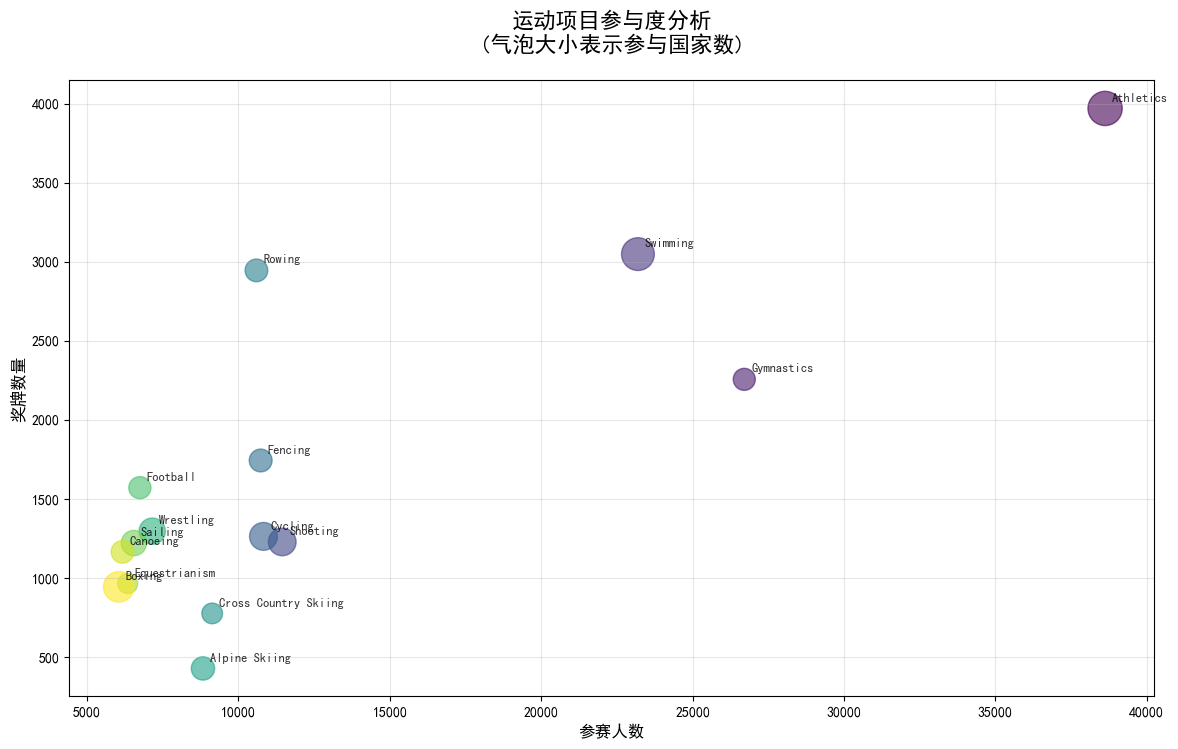

In [62]:
project_stats = combined.groupby('Sport').agg({
    'ID': 'count',
    'region': 'nunique',
    'Is_Medal': 'sum'
}).rename(columns={
    'ID': 'Participants',
    'region': 'Countries',
    'Is_Medal': 'Medals'
})
top_projects = project_stats.sort_values('Participants', ascending=False).head(15)
plt.figure(figsize=(14, 8))
scatter = plt.scatter(top_projects['Participants'], top_projects['Medals'], 
                     s=top_projects['Countries']*3, alpha=0.6, 
                     c=range(len(top_projects)), cmap='viridis')
for i, (sport, data) in enumerate(top_projects.iterrows()):
    plt.annotate(sport, (data['Participants'], data['Medals']), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=9, alpha=0.8)
plt.title('运动项目参与度分析\n(气泡大小表示参与国家数)', fontsize=16, pad=20)
plt.xlabel('参赛人数', fontsize=12)
plt.ylabel('奖牌数量', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

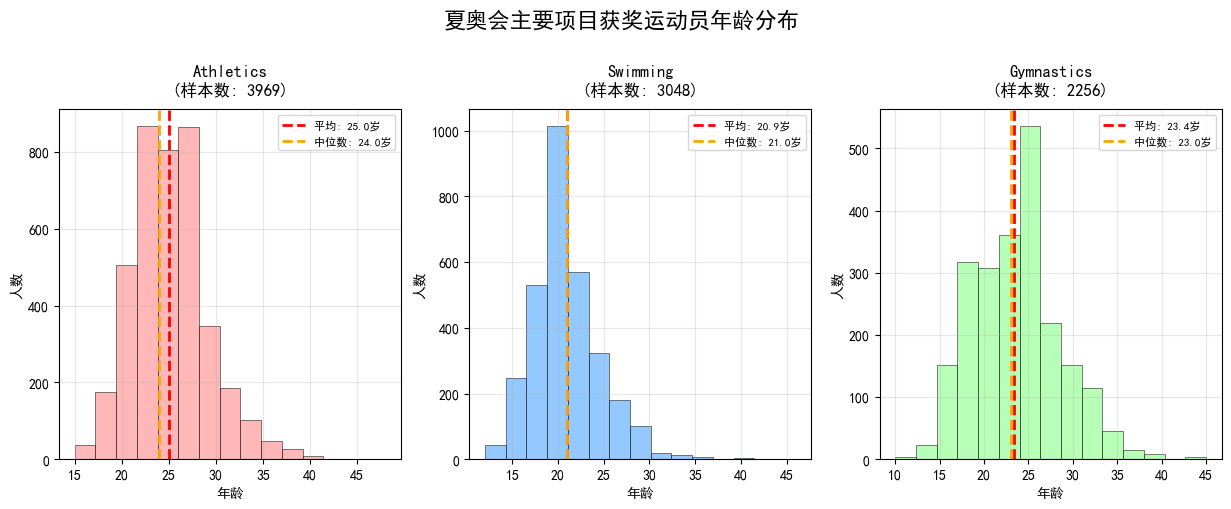

In [ ]:
medal_winners = combined[combined['Is_Medal'] == 1].copy()
major_sports = ['Athletics', 'Swimming', 'Gymnastics']
sports_available = [sport for sport in major_sports if sport in medal_winners['Sport'].values]
if sports_available:
    plt.figure(figsize=(15, 10))
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    for i, sport in enumerate(sports_available[:3]):
        plt.subplot(2, 3, i+1)
        sport_winners = medal_winners[medal_winners['Sport'] == sport]['Age']
        if len(sport_winners) > 0:
            plt.hist(sport_winners, bins=15, alpha=0.7, 
                    color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)
            mean_age = sport_winners.mean()
            median_age = sport_winners.median()
            
            plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, 
                       label=f'平均: {mean_age:.1f}岁')
            plt.axvline(median_age, color='orange', linestyle='--', linewidth=2, 
                       label=f'中位数: {median_age:.1f}岁')
            
            plt.title(f'{sport}\n(样本数: {len(sport_winners)})', fontsize=12, pad=10)
            plt.xlabel('年龄', fontsize=10)
            plt.ylabel('人数', fontsize=10)
            plt.legend(fontsize=8)
            plt.grid(True, alpha=0.3)
    plt.suptitle('夏奥会主要项目获奖运动员年龄分布', fontsize=16, y=0.98)
    plt.show()

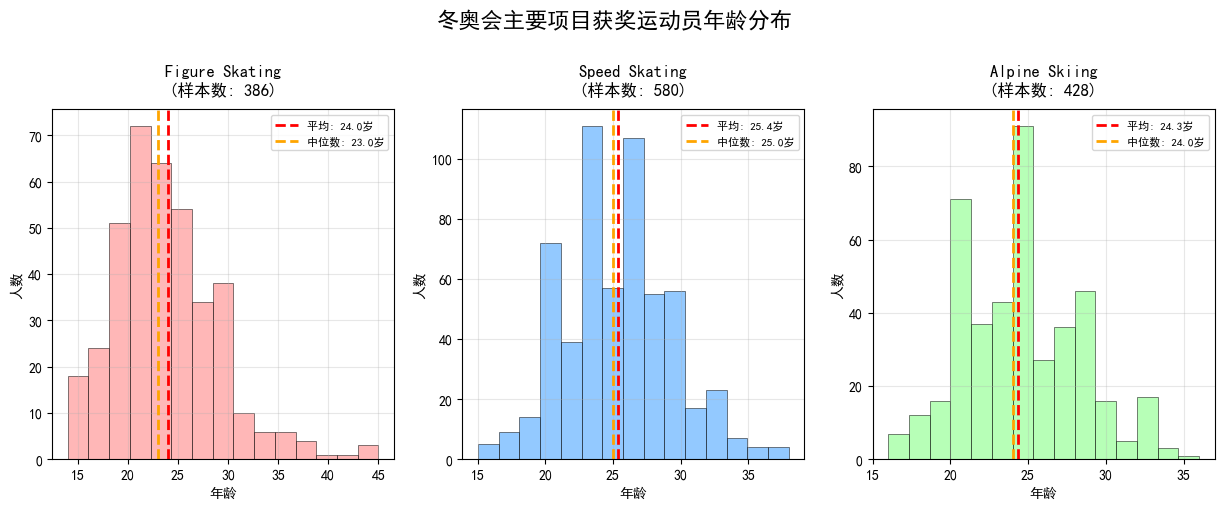

In [ ]:
medal_winners = combined[combined['Is_Medal'] == 1].copy()
major_sports = ['Figure Skating', 'Speed Skating', 'Alpine Skiing']
sports_available = [sport for sport in major_sports if sport in medal_winners['Sport'].values]
if sports_available:
    plt.figure(figsize=(15, 10))
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    for i, sport in enumerate(sports_available[:3]):
        plt.subplot(2, 3, i+1)
        sport_winners = medal_winners[medal_winners['Sport'] == sport]['Age']
        if len(sport_winners) > 0:
            plt.hist(sport_winners, bins=15, alpha=0.7, 
                    color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)
            mean_age = sport_winners.mean()
            median_age = sport_winners.median()
            
            plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, 
                       label=f'平均: {mean_age:.1f}岁')
            plt.axvline(median_age, color='orange', linestyle='--', linewidth=2, 
                       label=f'中位数: {median_age:.1f}岁')
            
            plt.title(f'{sport}\n(样本数: {len(sport_winners)})', fontsize=12, pad=10)
            plt.xlabel('年龄', fontsize=10)
            plt.ylabel('人数', fontsize=10)
            plt.legend(fontsize=8)
            plt.grid(True, alpha=0.3)
    plt.suptitle('冬奥会主要项目获奖运动员年龄分布', fontsize=16, y=0.98)
    plt.show()

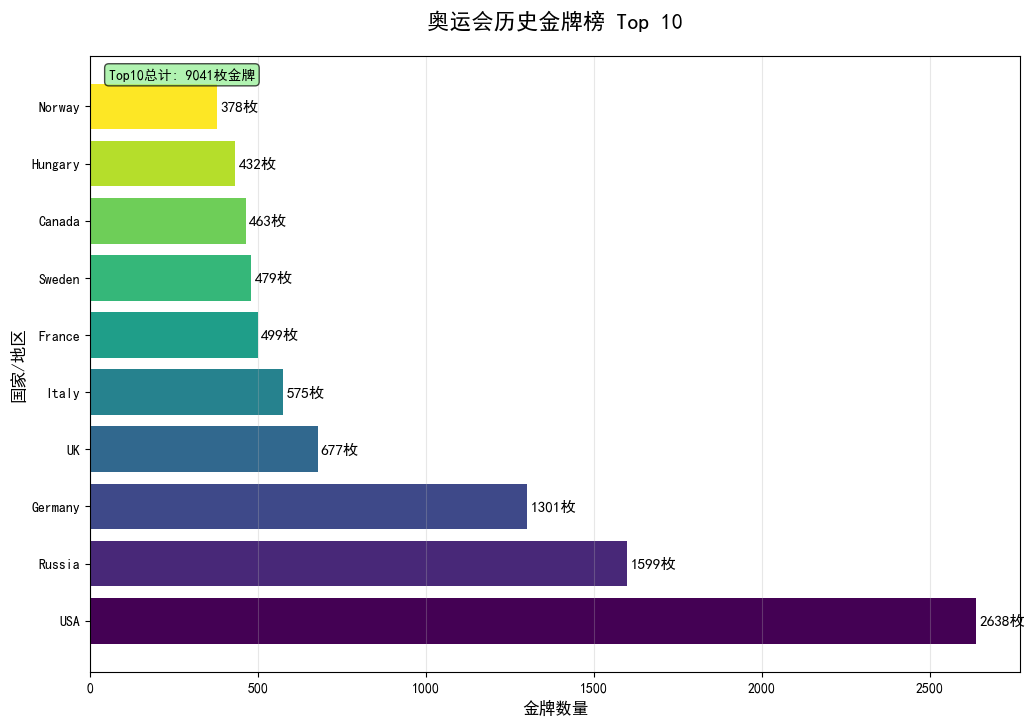

In [66]:
gold_medals = combined[combined['Medal'] == 'Gold'].groupby('region').size().sort_values(ascending=False).head(10)
gold_medals_1 = gold_medals.reset_index()
gold_medals_1.columns = ['Country', 'Gold_Medals']
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(gold_medals_1)), gold_medals_1['Gold_Medals'], 
                color=plt.cm.viridis(np.linspace(0, 1, len(gold_medals_1))))
plt.yticks(range(len(gold_medals_1)), gold_medals_1['Country'])

for i, (country, medals) in enumerate(gold_medals_1.values):
    plt.text(medals + 10, i, f'{medals}枚', 
             va='center', fontsize=11, fontweight='bold')

plt.title('奥运会历史金牌榜 Top 10', fontsize=16, pad=20)
plt.xlabel('金牌数量', fontsize=12)
plt.ylabel('国家/地区', fontsize=12)
plt.grid(axis='x', alpha=0.3)

total_medals = gold_medals_1['Gold_Medals'].sum()
plt.text(0.02, 0.98, f'Top10总计: {total_medals}枚金牌', 
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7),
         verticalalignment='top')

plt.show()

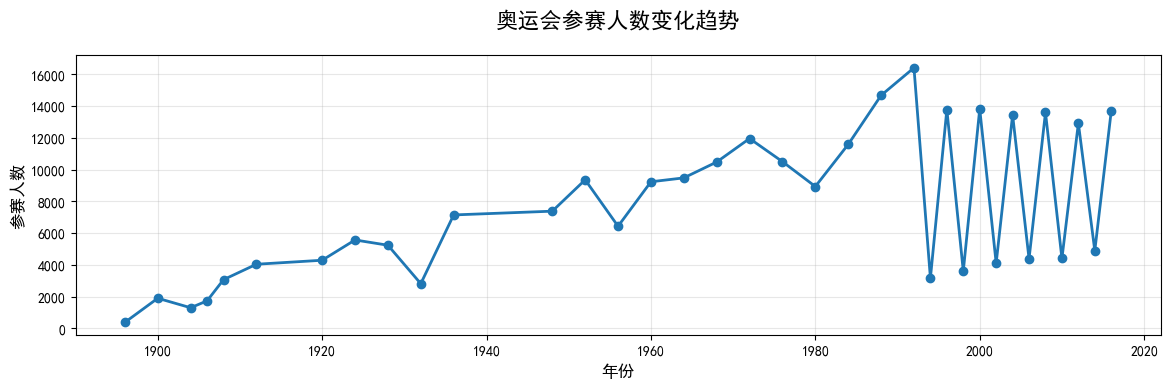

In [68]:
yearly_participants = combined.groupby('Year')['ID'].count().reset_index()
yearly_participants.columns = ['Year', 'Participants']
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(yearly_participants['Year'], yearly_participants['Participants'], 
         marker='o', linewidth=2, markersize=6, color='#1f77b4')
plt.title('奥运会参赛人数变化趋势', fontsize=16, pad=20)
plt.xlabel('年份', fontsize=12)
plt.ylabel('参赛人数', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

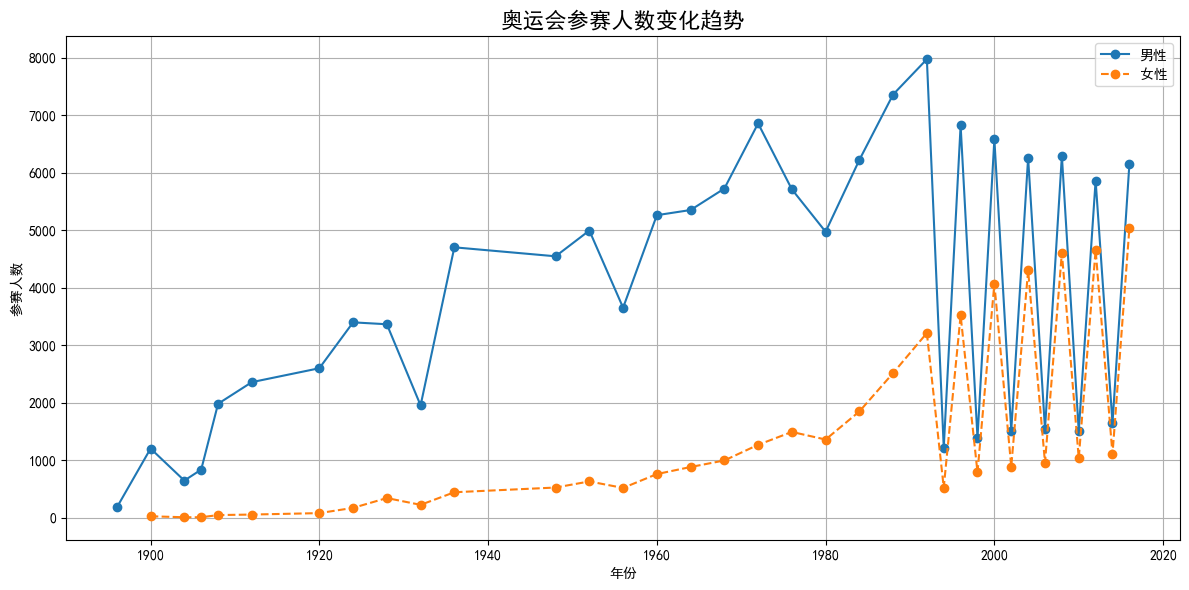

In [69]:
plt.figure(figsize=(12, 6))
gender_counts = combined.groupby(['Year', 'Sex'])['ID'].nunique().unstack()
plt.plot(gender_counts.index, gender_counts['M'], label='男性', marker='o', linestyle='-')
plt.plot(gender_counts.index, gender_counts['F'], label='女性', marker='o', linestyle='--')
plt.title('奥运会参赛人数变化趋势', fontsize=16)
plt.xlabel('年份')
plt.ylabel('参赛人数')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\W1900\AppData\Local\Temp\ipykernel_43928\276117401.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data_to_plot, labels=sports, patch_artist=True)


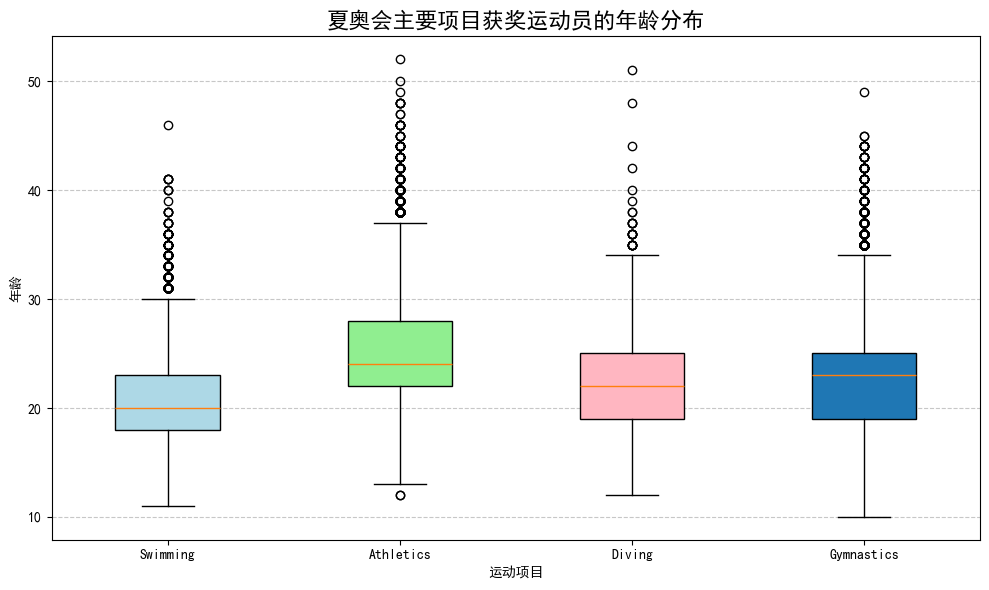

In [70]:
plt.figure(figsize=(10, 6))
sports = ['Swimming', 'Athletics', 'Diving', 'Gymnastics']
data_to_plot = []
for sport in sports:
    ages = combined[
        (combined['Sport'] == sport) & 
        (combined['Medal'] != 'No Medal')
    ]['Age'].dropna()
 
    data_to_plot.append(ages)
bplot = plt.boxplot(data_to_plot, labels=sports, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightpink']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
plt.title('夏奥会主要项目获奖运动员的年龄分布', fontsize=16)
plt.ylabel('年龄')
plt.xlabel('运动项目')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\W1900\AppData\Local\Temp\ipykernel_43928\2789846582.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data_to_plot, labels=sports, patch_artist=True)


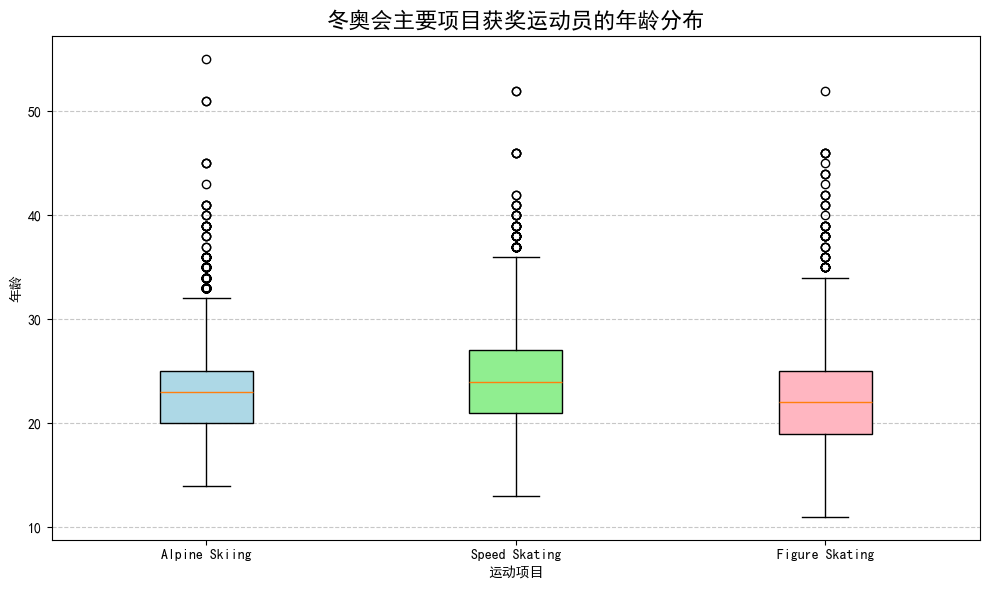

In [71]:
plt.figure(figsize=(10, 6))
sports = ['Alpine Skiing', 'Speed Skating', 'Figure Skating']
data_to_plot = []
for sport in sports:
    ages = combined[
        (combined['Sport'] == sport) & 
        (combined['Medal'] != 'No Medal')
    ]['Age'].dropna()
    data_to_plot.append(ages)
bplot = plt.boxplot(data_to_plot, labels=sports, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightpink']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
plt.title('冬奥会主要项目获奖运动员的年龄分布', fontsize=16)
plt.ylabel('年龄')
plt.xlabel('运动项目')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

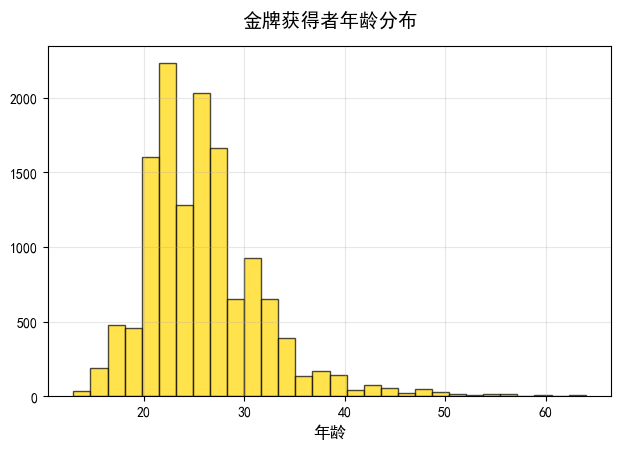

In [72]:
gold_winners = combined[combined['Medal'] == 'Gold'].copy()
plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1)
plt.hist(gold_winners['Age'].dropna(), bins=30, alpha=0.7, color='gold', edgecolor='black')
plt.title('金牌获得者年龄分布', fontsize=14, pad=15)
plt.xlabel('年龄', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

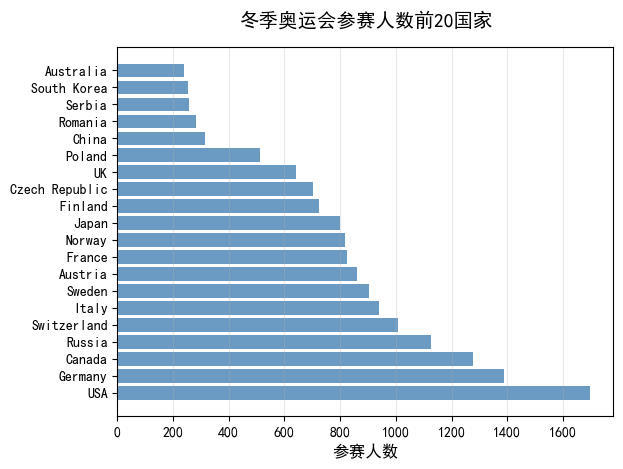

In [73]:
winter = combined[combined['Season'] == 'Winter'].copy()
if len(winter) > 0:
    winter_country_stats = winter.groupby('region').agg({
        'ID': 'nunique',
        'Is_Medal': 'sum'
    }).reset_index()
    winter_country_stats.columns = ['Country', 'Total_Participants', 'Total_Medals']
    winter_top_countries = winter_country_stats.sort_values('Total_Participants', ascending=False).head(20)

    plt.barh(range(len(winter_top_countries)), winter_top_countries['Total_Participants'], 
             color='steelblue', alpha=0.8)
    plt.yticks(range(len(winter_top_countries)), winter_top_countries['Country'], fontsize=10)
    plt.xlabel('参赛人数', fontsize=12)
    plt.title('冬季奥运会参赛人数前20国家', fontsize=14, pad=15)
    plt.grid(axis='x', alpha=0.3)
    plt.show()



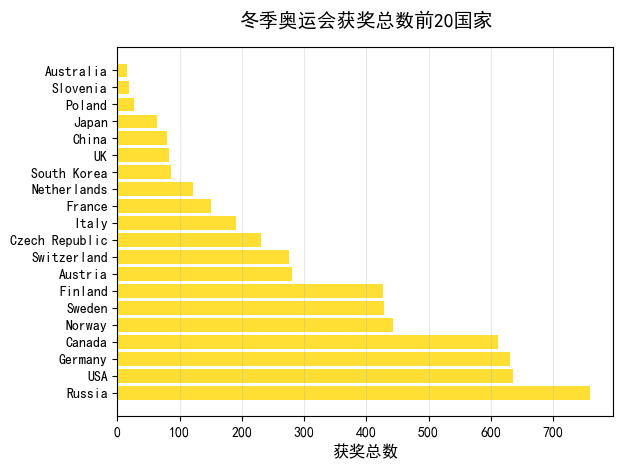

In [19]:
winter_medal_top = winter_country_stats.sort_values('Total_Medals', ascending=False).head(20)
plt.barh(range(len(winter_medal_top)), winter_medal_top['Total_Medals'], 
        color='gold', alpha=0.8)
plt.yticks(range(len(winter_medal_top)), winter_medal_top['Country'], fontsize=10)
plt.xlabel('获奖总数', fontsize=12)
plt.title('冬季奥运会获奖总数前20国家', fontsize=14, pad=15)
plt.grid(axis='x', alpha=0.3)
plt.show()

未映射的区域: [nan]
全球各区域奖牌贡献度统计:
大洲 奖牌数 贡献度 参赛国家数
Europe 25467 0.64 48          
North America 7779 0.2 30          
Asia 3429 0.09 44          
Oceania 1591 0.04 16          
South America 924 0.02 12          
Africa 568 0.01 54          
Others 14 0.0 1           


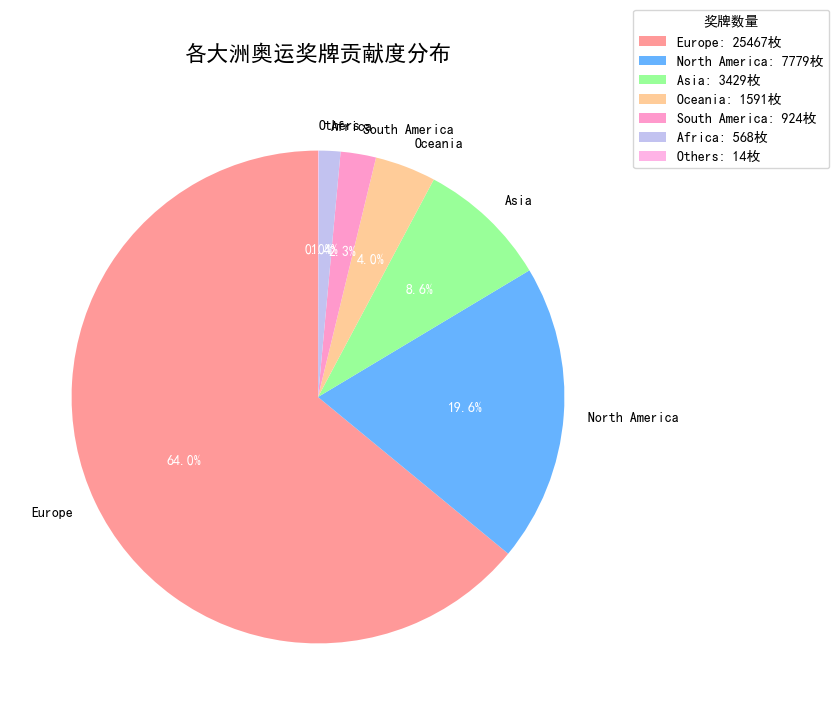

In [ ]:
region_to_continent = {
    'Denmark': 'Europe', 'Germany': 'Europe', 'Italy': 'Europe', 'Norway': 'Europe', 
    'Poland': 'Europe', 'Sweden': 'Europe', 'Switzerland': 'Europe', 'UK': 'Europe',
    'France': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Belgium': 'Europe',
    'Ireland': 'Europe', 'Portugal': 'Europe', 'Austria': 'Europe', 'Finland': 'Europe',
    'Greece': 'Europe', 'Croatia': 'Europe', 'Czech Republic': 'Europe', 'Hungary': 'Europe',
    'Russia': 'Europe', 'Belarus': 'Europe', 'Romania': 'Europe', 'Bulgaria': 'Europe',
    'Serbia': 'Europe', 'Slovenia': 'Europe', 'Slovakia': 'Europe', 'Estonia': 'Europe',
    'Latvia': 'Europe', 'Lithuania': 'Europe', 'Ukraine': 'Europe', 'Moldova': 'Europe',
    'Iceland': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Cyprus': 'Europe',
    'Montenegro': 'Europe', 'Bosnia and Herzegovina': 'Europe', 'Macedonia': 'Europe',
    'Albania': 'Europe', 'Armenia': 'Europe', 'Georgia': 'Europe', 'Azerbaijan': 'Europe', 'Monaco': 'Europe',
    
    'USA': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Guatemala': 'North America', 'Belize': 'North America', 'El Salvador': 'North America',
    'Honduras': 'North America', 'Nicaragua': 'North America', 'Costa Rica': 'North America',
    'Panama': 'North America', 'Cuba': 'North America', 'Jamaica': 'North America',
    'Haiti': 'North America', 'Dominican Republic': 'North America', 'Bahamas': 'North America',
    'Trinidad and Tobago': 'North America', 'Barbados': 'North America', 'Saint Lucia': 'North America',
    'Grenada': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Antigua and Barbuda': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Dominica': 'North America', 'Bermuda': 'North America', 'Puerto Rico': 'North America',
    
    'China': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia', 'India': 'Asia',
    'Thailand': 'Asia', 'Vietnam': 'Asia', 'Malaysia': 'Asia', 'Singapore': 'Asia',
    'Indonesia': 'Asia', 'Philippines': 'Asia', 'Myanmar': 'Asia', 'Cambodia': 'Asia',
    'Laos': 'Asia', 'Brunei': 'Asia', 'Mongolia': 'Asia', 'North Korea': 'Asia',
    'Taiwan': 'Asia', 'Hong Kong': 'Asia', 'Macao': 'Asia', 'Iran': 'Asia',
    'Iraq': 'Asia', 'Syria': 'Asia', 'Lebanon': 'Asia', 'Jordan': 'Asia',
    'Israel': 'Asia', 'Palestine': 'Asia', 'Saudi Arabia': 'Asia', 'Yemen': 'Asia',
    'Oman': 'Asia', 'UAE': 'Asia', 'Qatar': 'Asia', 'Bahrain': 'Asia',
    'Kuwait': 'Asia', 'Afghanistan': 'Asia', 'Pakistan': 'Asia', 'Bangladesh': 'Asia',
    'Sri Lanka': 'Asia', 'Nepal': 'Asia', 'Bhutan': 'Asia', 'Maldives': 'Asia',
    'Myanmar': 'Asia','United Arab Emirates': 'Asia', 'Turkey': 'Asia', 'Kazakhstan': 'Asia', 
    'Uzbekistan': 'Asia', 'Kyrgyzstan': 'Asia', 'Tajikistan': 'Asia', 'Turkmenistan': 'Asia', 
    
    'South Africa': 'Africa', 'Egypt': 'Africa', 'Kenya': 'Africa', 'Ethiopia': 'Africa',
    'Nigeria': 'Africa', 'Ghana': 'Africa', 'Morocco': 'Africa', 'Tunisia': 'Africa',
    'Algeria': 'Africa', 'Libya': 'Africa', 'Sudan': 'Africa', 'South Sudan': 'Africa',
    'Cameroon': 'Africa', 'Ivory Coast': 'Africa', 'Senegal': 'Africa', 'Mali': 'Africa',
    'Burkina Faso': 'Africa', 'Niger': 'Africa', 'Chad': 'Africa', 'Guinea': 'Africa',
    'Benin': 'Africa', 'Togo': 'Africa', 'Sierra Leone': 'Africa', 'Liberia': 'Africa',
    'Gambia': 'Africa', 'Cape Verde': 'Africa', 'Mauritania': 'Africa', 'Djibouti': 'Africa',
    'Somalia': 'Africa', 'Eritrea': 'Africa', 'Madagascar': 'Africa', 'Mauritius': 'Africa',
    'Comoros': 'Africa', 'Seychelles': 'Africa', 'Equatorial Guinea': 'Africa',
    'Gabon': 'Africa', 'Republic of the Congo': 'Africa', 'Democratic Republic of the Congo': 'Africa',
    'Central African Republic': 'Africa', 'Uganda': 'Africa', 'Tanzania': 'Africa',
    'Rwanda': 'Africa', 'Burundi': 'Africa', 'Malawi': 'Africa', 'Zambia': 'Africa',
    'Zimbabwe': 'Africa', 'Botswana': 'Africa', 'Namibia': 'Africa', 'Angola': 'Africa',
    'Mozambique': 'Africa',
    
    'Brazil': 'South America', 'Argentina': 'South America', 'Chile': 'South America',
    'Peru': 'South America', 'Colombia': 'South America', 'Venezuela': 'South America',
    'Ecuador': 'South America', 'Bolivia': 'South America', 'Paraguay': 'South America',
    'Uruguay': 'South America', 'Guyana': 'South America', 'Suriname': 'South America',
    'French Guiana': 'South America',
    
    'Australia': 'Oceania', 'New Zealand': 'Oceania', 'Fiji': 'Oceania', 'Papua New Guinea': 'Oceania',
    'Samoa': 'Oceania', 'Tonga': 'Oceania', 'Solomon Islands': 'Oceania', 'Vanuatu': 'Oceania',
    'Palau': 'Oceania', 'Marshall Islands': 'Oceania', 'Micronesia': 'Oceania', 'Nauru': 'Oceania',
    'Tuvalu': 'Oceania', 'Kiribati': 'Oceania', 'Cook Islands': 'Oceania', 'Niue': 'Oceania',
    'Tokelau': 'Oceania', 'American Samoa': 'Oceania', 'Guam': 'Oceania', 'Northern Mariana Islands': 'Oceania',

    'Republic of Congo': 'Africa',
    'Virgin Islands, US': 'North America',
    'Saint Kitts': 'North America',
    'Trinidad': 'North America',
    'Saint Vincent': 'North America',
    'Curacao': 'North America',
    'Individual Olympic Athletes': 'Others',
    'Virgin Islands, British': 'North America',
    'Cayman Islands': 'North America',
    'Guinea-Bissau': 'Africa',
    'Timor-Leste': 'Asia',
    'San Marino': 'Europe',
    'Boliva': 'South America',
    'Andorra': 'Europe',
    'Antigua': 'North America',
    'Sao Tome and Principe': 'Africa',
    'Liechtenstein': 'Europe',
    'Swaziland': 'Africa',
    'Aruba': 'North America',
    'Kosovo': 'Europe',
    'Lesotho': 'Africa'
}

combined['Continent'] = combined['region'].map(region_to_continent)


unmapped_regions = combined[combined['Continent'].isna()]['region'].unique()
if len(unmapped_regions) > 0:
    print(f"未映射的区域: {list(unmapped_regions)}")
    combined['Continent'] = combined['Continent'].fillna('Others')


continent_medals = combined[combined['Is_Medal'] == 1].groupby('Continent').size().reset_index()
continent_medals.columns = ['Continent', 'Total_Medals']
continent_medals = continent_medals.sort_values('Total_Medals', ascending=False)


total_medals = continent_medals['Total_Medals'].sum()
continent_medals['Contribution_Percent'] = (continent_medals['Total_Medals'] / total_medals).round(2)


continent_countries = combined.groupby('Continent')['region'].nunique().reset_index()
continent_countries.columns = ['Continent', 'Participating_Countries']


continent_analysis = pd.merge(continent_medals, continent_countries, on='Continent')

print("全球各区域奖牌贡献度统计:")

print(f"{'大洲'} {'奖牌数'} {'贡献度'} {'参赛国家数'}")


for _, row in continent_analysis.iterrows():
    print(f"{row['Continent']} {row['Total_Medals']} {row['Contribution_Percent']} {row['Participating_Countries']:<12}")
plt.figure(figsize=(12, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0', '#ffb3e6']
wedges, texts, autotexts = plt.pie(continent_analysis['Total_Medals'], 
                                  labels=continent_analysis['Continent'],
                                  autopct='%1.1f%%',
                                  colors=colors[:len(continent_analysis)],
                                  startangle=90,)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.title('各大洲奥运奖牌贡献度分布', fontsize=16, pad=20)

legend_labels = [f"{row['Continent']}: {row['Total_Medals']}枚" for _, row in continent_analysis.iterrows()]
plt.legend(wedges, legend_labels, title="奖牌数量", loc="center left", bbox_to_anchor=(1, 1, 0.5, 0))
plt.show()

各大洲参赛人数和获奖人数占比统计:
大洲 参赛人数 参赛占比 获奖人数 获奖占比 获奖率
Europe          161597 0.6 25467 0.64 0.16
North America   39285 0.15 7779 0.2 0.2
Asia            33652 0.12 3429 0.09 0.1
Africa          11978 0.04 568 0.01 0.05
South America   11901 0.04 924 0.02 0.08
Oceania         10854 0.04 1591 0.04 0.15
Others          464 0.0 14 0.0 0.03


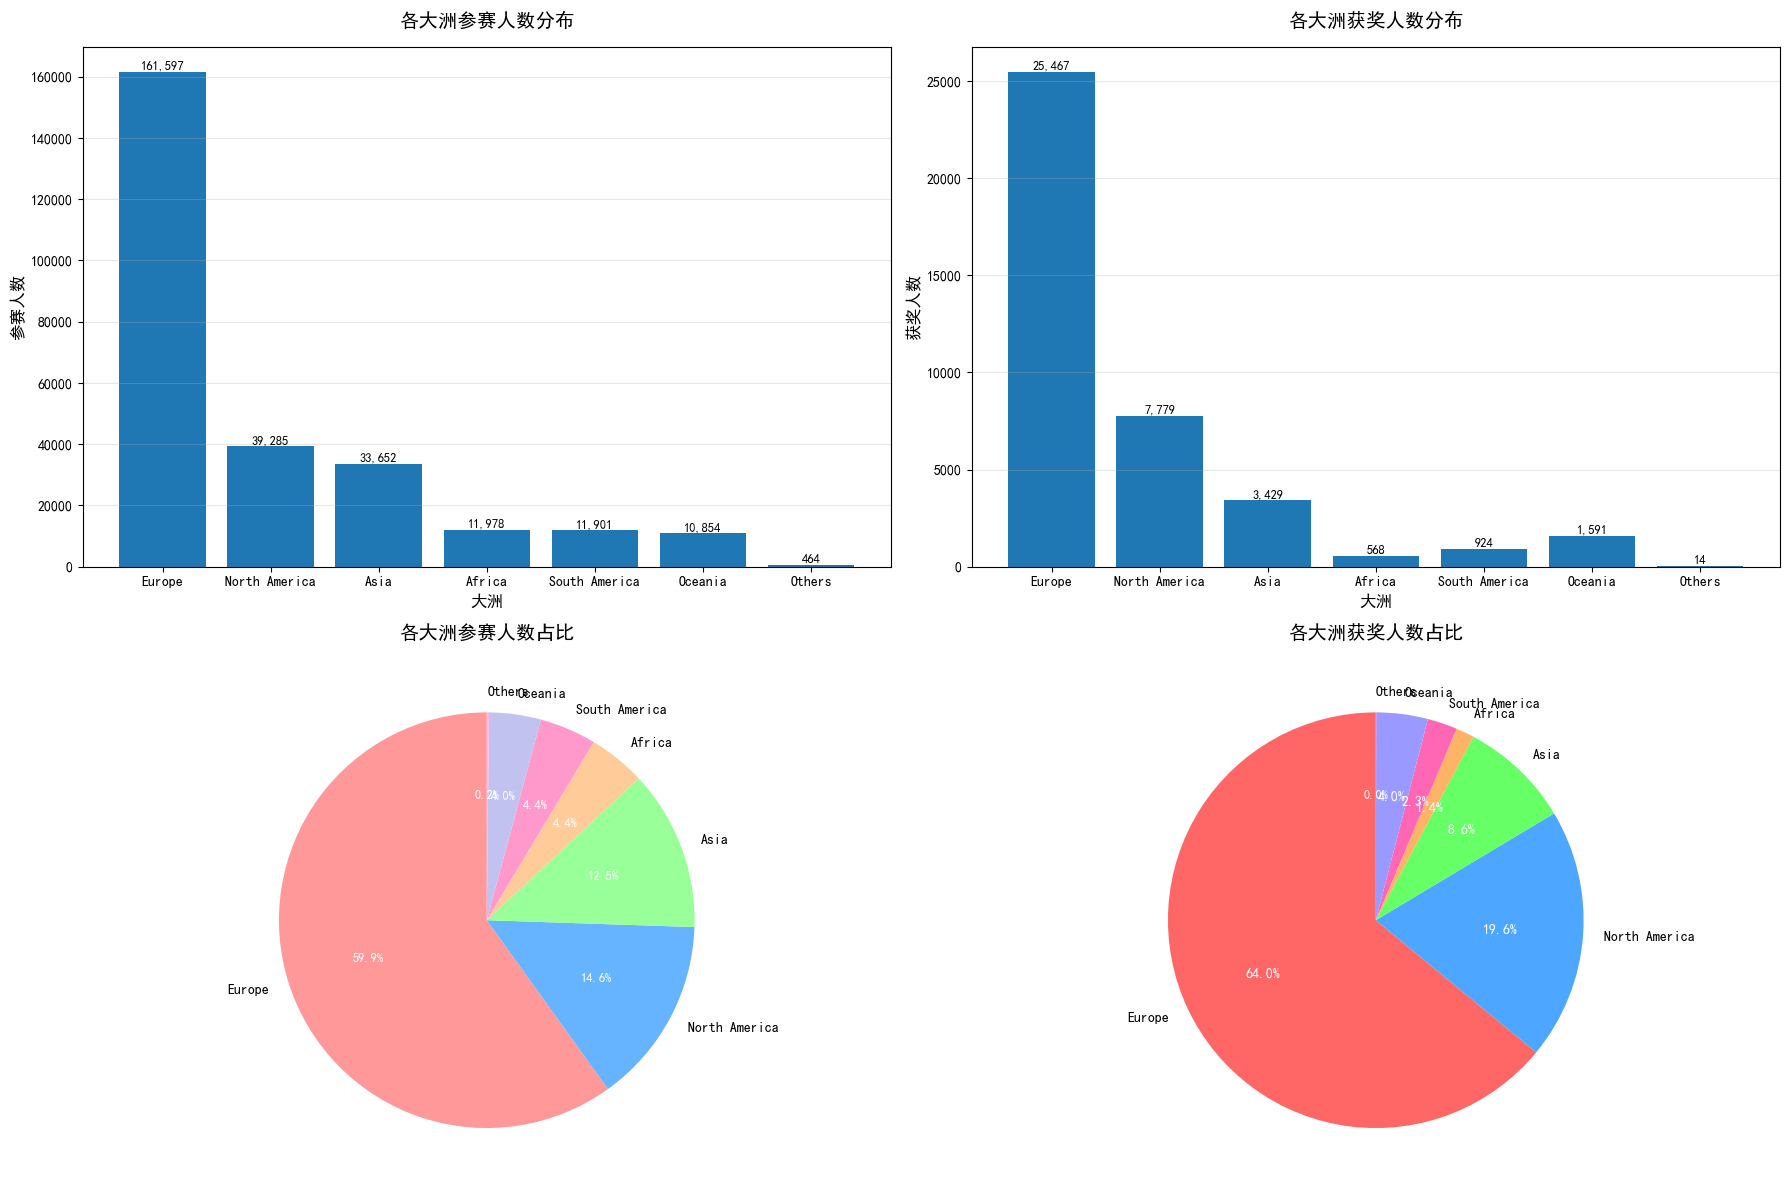

In [75]:
continent_participation = combined.groupby('Continent').agg({
'ID': 'count',
'Is_Medal': 'sum',
}).reset_index()
continent_participation.columns = ['Continent', 'Total_Participants', 'Total_Medals']
total_participants = continent_participation['Total_Participants'].sum()
total_medals = continent_participation['Total_Medals'].sum()
continent_participation['Participant_Percent'] = (continent_participation['Total_Participants'] / total_participants).round(2)
continent_participation['Medal_Percent'] = (continent_participation['Total_Medals'] / total_medals).round(2)
continent_participation['Medal_Rate'] = (continent_participation['Total_Medals'] / continent_participation['Total_Participants']).round(2)
continent_participation = continent_participation.sort_values('Total_Participants', ascending=False)
print("各大洲参赛人数和获奖人数占比统计:")
print(f"{'大洲'} {'参赛人数'} {'参赛占比'} {'获奖人数'} {'获奖占比'} {'获奖率'}")
for _, row in continent_participation.iterrows():
    print(f"{row['Continent']:<15} {row['Total_Participants']} {row['Participant_Percent']} {row['Total_Medals']} {row['Medal_Percent']} {row['Medal_Rate']}")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))


colors_participants = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0', '#ffb3e6']
bars1 = axes[0, 0].bar(continent_participation['Continent'], continent_participation['Total_Participants'])

axes[0, 0].set_title('各大洲参赛人数分布', fontsize=14, pad=15)
axes[0, 0].set_xlabel('大洲', fontsize=12)
axes[0, 0].set_ylabel('参赛人数', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,f'{int(height):,}',
                    ha='center', va='bottom', fontsize=9)

colors_medals = ['#ff6666', '#4da6ff', '#66ff66', '#ffb366', '#ff66b3', '#9999ff', '#ff66cc']
bars2 = axes[0, 1].bar(continent_participation['Continent'], continent_participation['Total_Medals'])

axes[0, 1].set_title('各大洲获奖人数分布', fontsize=14, pad=15)
axes[0, 1].set_xlabel('大洲', fontsize=12)
axes[0, 1].set_ylabel('获奖人数', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,f'{int(height):,}',
                    ha='center', va='bottom', fontsize=9)

wedges1, texts1, autotexts1 = axes[1, 0].pie(continent_participation['Total_Participants'],
                                              labels=continent_participation['Continent'],
                                              autopct='%1.1f%%',
                                              colors=colors_participants[:len(continent_participation)],
                                              startangle=90)
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)
    axes[1, 0].set_title('各大洲参赛人数占比', fontsize=14, pad=15)

wedges2, texts2, autotexts2 = axes[1, 1].pie(continent_participation['Total_Medals'],
                                              labels=continent_participation['Continent'],
                                              autopct='%1.1f%%',
                                              colors=colors_medals[:len(continent_participation)],
                                              startangle=90)
                                        
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
autotext.set_fontsize(9)
axes[1, 1].set_title('各大洲获奖人数占比', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

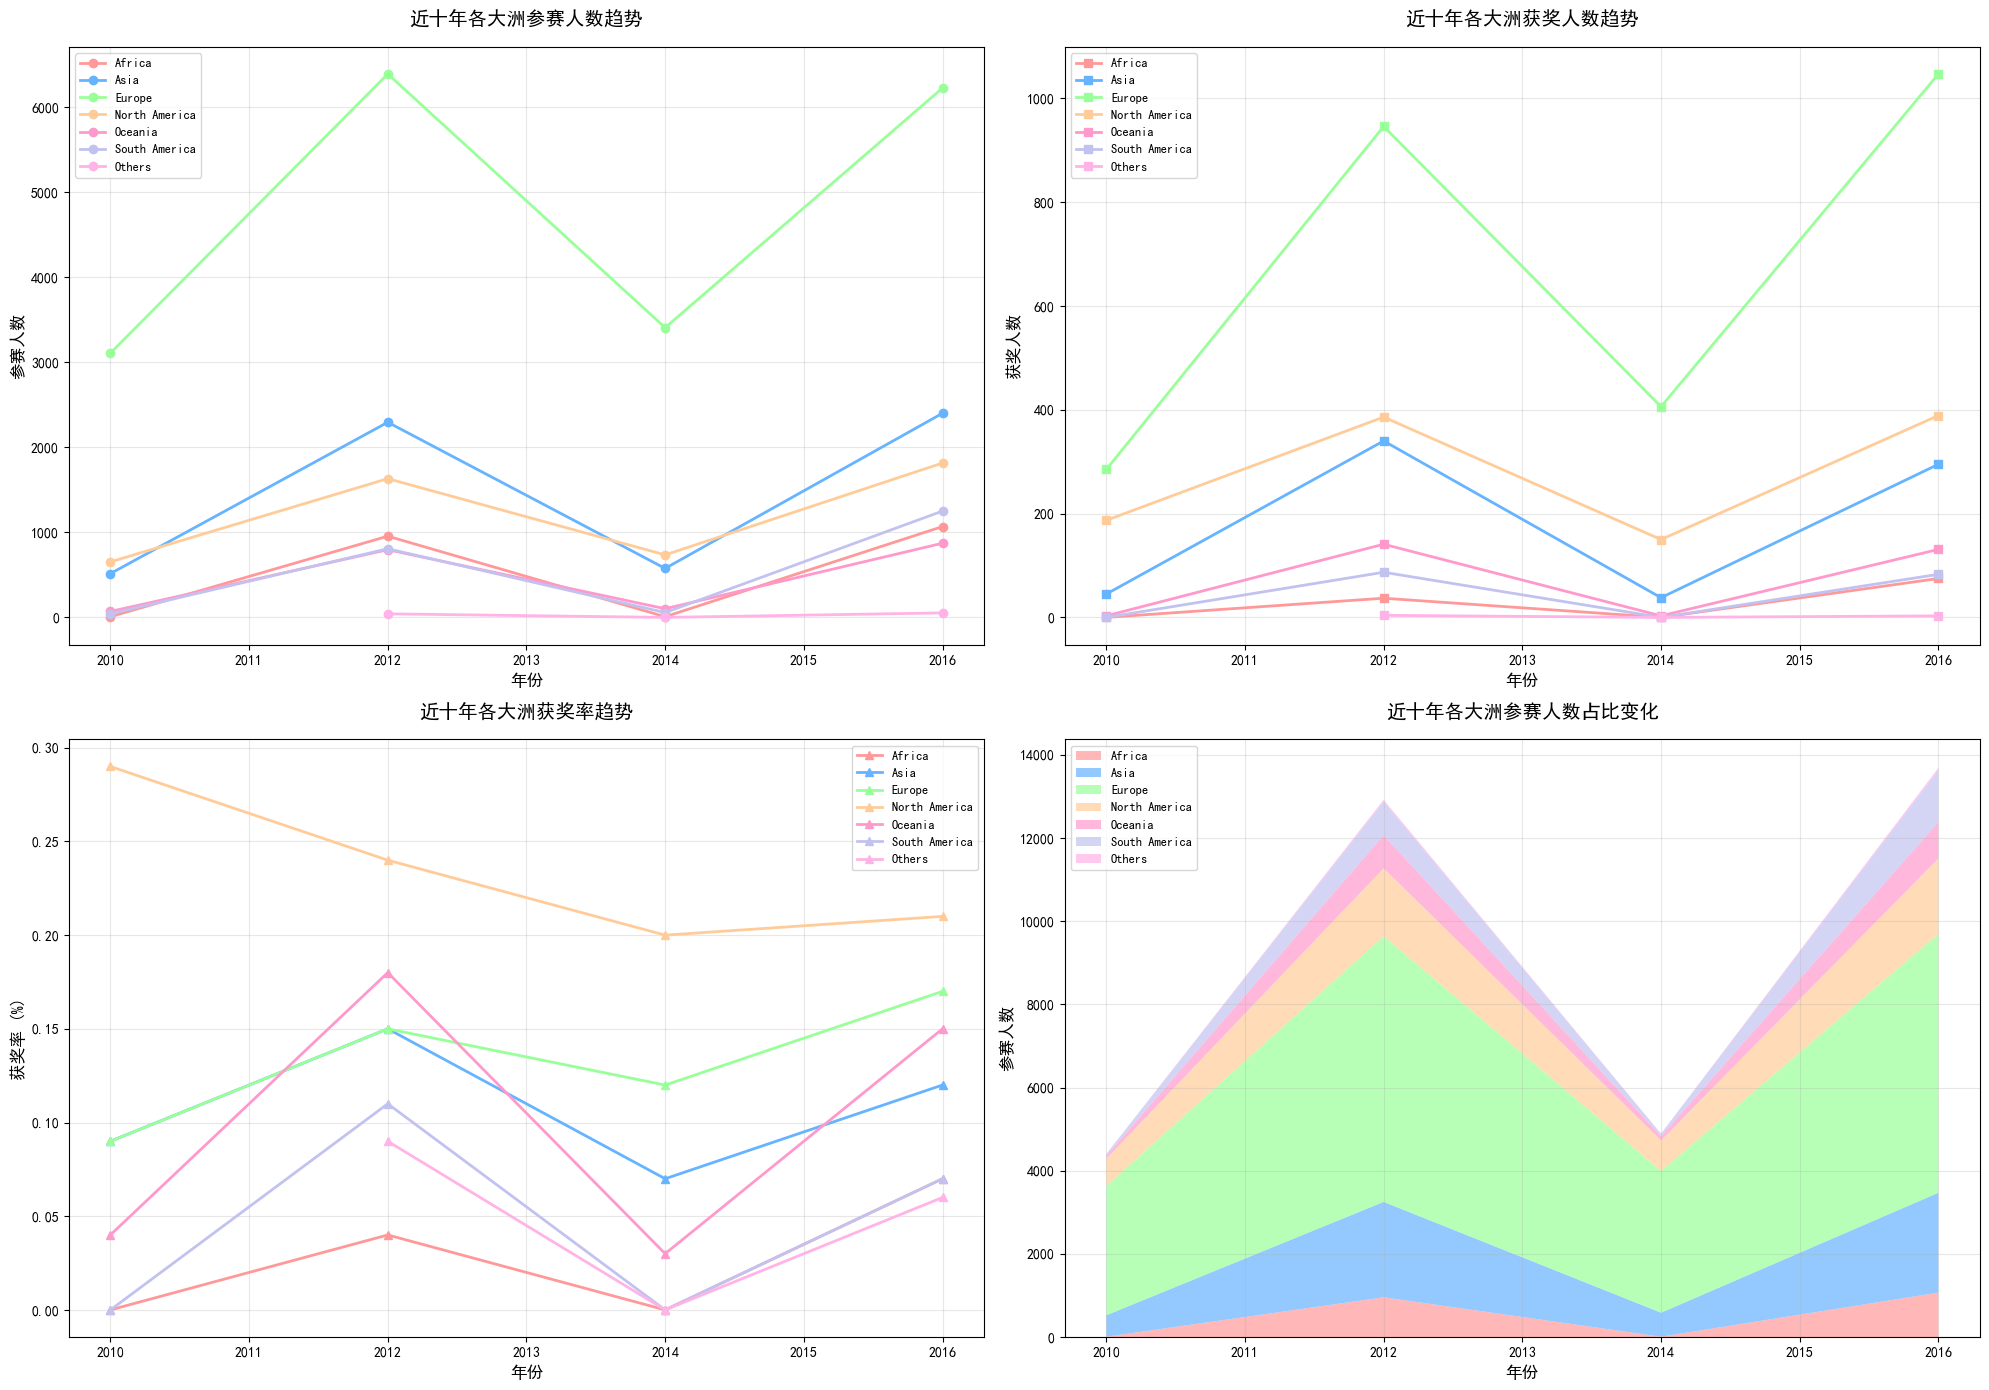

Africa:
平均参赛人数: 511人
平均获奖人数: 28人
平均获奖率: 0.03
参赛人数变化: +1060人 (+117.8)
获奖人数变化: +75人 (+inf)
Asia:
平均参赛人数: 1447人
平均获奖人数: 180人
平均获奖率: 0.11
参赛人数变化: +1885人 (+3.7)
获奖人数变化: +250人 (+5.6)
Europe:
平均参赛人数: 4782人
平均获奖人数: 671人
平均获奖率: 0.13
参赛人数变化: +3116人 (+1.0)
获奖人数变化: +762人 (+2.7)
North America:
平均参赛人数: 1210人
平均获奖人数: 278人
平均获奖率: 0.23
参赛人数变化: +1162人 (+1.8)
获奖人数变化: +202人 (+1.1)
Oceania:
平均参赛人数: 461人
平均获奖人数: 70人
平均获奖率: 0.10
参赛人数变化: +802人 (+11.3)
获奖人数变化: +128人 (+42.7)
South America:
平均参赛人数: 540人
平均获奖人数: 42人
平均获奖率: 0.04
参赛人数变化: +1207人 (+27.4)
获奖人数变化: +83人 (+inf)
Others:
平均参赛人数: 33人
平均获奖人数: 2人
平均获奖率: 0.05
参赛人数变化: +11人 (+0.3)
获奖人数变化: -1人 (-0.2)


C:\Users\W1900\AppData\Local\Temp\ipykernel_43928\2002229523.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"获奖人数变化: {growth_medals:+.0f}人 ({growth_medals/continent_data.iloc[0]['Medals']:+.1f})")


In [76]:
recent_years = combined[combined['Year'] >= 2010].copy()
continent_yearly = recent_years.groupby(['Year', 'Continent']).agg({
    'ID': 'count',
    'Is_Medal': 'sum'
}).reset_index()
continent_yearly.columns = ['Year', 'Continent', 'Participants', 'Medals']

continent_yearly['Medal_Rate'] = (continent_yearly['Medals'] / continent_yearly['Participants']).round(2)
continents = continent_yearly['Continent'].unique()
years = sorted(continent_yearly['Year'].unique())


fig, axes = plt.subplots(2, 2, figsize=(20, 14))

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0', '#ffb3e6']
color_dict = {continent: colors[i % len(colors)] for i, continent in enumerate(continents)}


for continent in continents:
    continent_data = continent_yearly[continent_yearly['Continent'] == continent]
    axes[0, 0].plot(continent_data['Year'], continent_data['Participants'], 
                    marker='o', linewidth=2, markersize=6, 
                    label=continent, color=color_dict[continent])

axes[0, 0].set_title('近十年各大洲参赛人数趋势', fontsize=14, pad=15)
axes[0, 0].set_xlabel('年份', fontsize=12)
axes[0, 0].set_ylabel('参赛人数', fontsize=12)
axes[0, 0].legend(loc='best', fontsize=9)
axes[0, 0].grid(True, alpha=0.3)


for continent in continents:
    continent_data = continent_yearly[continent_yearly['Continent'] == continent]
    axes[0, 1].plot(continent_data['Year'], continent_data['Medals'], 
                    marker='s', linewidth=2, markersize=6, 
                    label=continent, color=color_dict[continent])

axes[0, 1].set_title('近十年各大洲获奖人数趋势', fontsize=14, pad=15)
axes[0, 1].set_xlabel('年份', fontsize=12)
axes[0, 1].set_ylabel('获奖人数', fontsize=12)
axes[0, 1].legend(loc='best', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)


for continent in continents:
    continent_data = continent_yearly[continent_yearly['Continent'] == continent]
    axes[1, 0].plot(continent_data['Year'], continent_data['Medal_Rate'], 
                    marker='^', linewidth=2, markersize=6, 
                    label=continent, color=color_dict[continent])

axes[1, 0].set_title('近十年各大洲获奖率趋势', fontsize=14, pad=15)
axes[1, 0].set_xlabel('年份', fontsize=12)
axes[1, 0].set_ylabel('获奖率 (%)', fontsize=12)
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

pivot_participants = continent_yearly.pivot(index='Year', columns='Continent', values='Participants').fillna(0)
pivot_participants = pivot_participants[continents]

axes[1, 1].stackplot(years, *[pivot_participants[continent] for continent in continents], 
                     labels=continents, colors=[color_dict[continent] for continent in continents], 
                     alpha=0.7)
axes[1, 1].set_title('近十年各大洲参赛人数占比变化', fontsize=14, pad=15)
axes[1, 1].set_xlabel('年份', fontsize=12)
axes[1, 1].set_ylabel('参赛人数', fontsize=12)
axes[1, 1].legend(loc='upper left', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for continent in continents:
    continent_data = continent_yearly[continent_yearly['Continent'] == continent]
    avg_participants = continent_data['Participants'].mean()
    avg_medals = continent_data['Medals'].mean()
    avg_medal_rate = continent_data['Medal_Rate'].mean()
    
    growth_participants = continent_data.iloc[-1]['Participants'] - continent_data.iloc[0]['Participants']
    growth_medals = continent_data.iloc[-1]['Medals'] - continent_data.iloc[0]['Medals']
    
    print(f"{continent}:")
    print(f"平均参赛人数: {avg_participants:.0f}人")
    print(f"平均获奖人数: {avg_medals:.0f}人")
    print(f"平均获奖率: {avg_medal_rate:.2f}")
    print(f"参赛人数变化: {growth_participants:+.0f}人 ({growth_participants/continent_data.iloc[0]['Participants']:+.1f})")
    print(f"获奖人数变化: {growth_medals:+.0f}人 ({growth_medals/continent_data.iloc[0]['Medals']:+.1f})")
